# Deep Learning Forum 04: Klasifikasi Makanan Indonesia dengan CNN

Notebook ini menyajikan pipeline end-to-end untuk klasifikasi gambar makanan Indonesia menggunakan Convolutional Neural Network (CNN). Alur kerja mencakup akuisisi dataset dari Kaggle, pelabelan data berdasarkan struktur folder, analisis eksploratif data (EDA), preprocessing gambar ke ukuran `224 x 224`, pelatihan model CNN kustom, serta perbandingan dengan model transfer learning berbasis VGG16.

Fokus evaluasi utama pada tugas ini adalah:
1. konsistensi pipeline pengolahan data citra,
2. kualitas generalisasi model pada data validasi dan pengujian,
3. perbandingan kinerja antara arsitektur CNN sederhana dan transfer learning.

In [ ]:
import os

# Inisiasi token cukup sekali di cell ini.
# Isi token Anda secara lokal saat runtime, lalu jangan simpan nilai token pada notebook.
KAGGLE_API_TOKEN = ''  # Kosongkan di repository untuk keamanan.

if KAGGLE_API_TOKEN.strip():
    os.environ['KAGGLE_API_TOKEN'] = KAGGLE_API_TOKEN.strip()
else:
    # Fallback ke environment sistem jika sudah diset dari terminal/OS.
    os.environ['KAGGLE_API_TOKEN'] = os.getenv('KAGGLE_API_TOKEN', '').strip()

In [ ]:
from typing import List, Dict

In [11]:
import os
import warnings
import tensorflow as tf

warnings.filterwarnings("ignore", message=".*IProgress not found.*")

# TensorFlow >= 2.11 on native Windows does not support GPU.
if os.name == "nt":
    os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
tf.get_logger().setLevel("ERROR")

# List available hardware
if os.name == "nt":
    devices: List = tf.config.list_physical_devices("CPU")
else:
    devices = tf.config.list_physical_devices()

print(f"Devices found: {devices}")

Devices found: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [12]:
if os.name == "nt":
    print("Running on Local CPU (native Windows TensorFlow build)")
else:
    gpu_devices: List = tf.config.list_physical_devices("GPU")

    if gpu_devices:
        print(f"GPU devices found: {gpu_devices}")

        for each_gpu_device in gpu_devices:
            tf.config.experimental.set_memory_growth(each_gpu_device, True)

    else:
        print("Running on Local CPU")

Running on Local CPU (native Windows TensorFlow build)


## Pengambilan Dataset

Pada notebook ini, dataset yang digunakan adalah `Indonesian Food Dataset` dari [Kaggle](https://www.kaggle.com/datasets/rizkyyk/dataset-food-classification).

### Deskripsi Dataset

Dataset berisi gambar makanan yang telah dikelompokkan ke dalam folder kelas dan dipisahkan ke dalam subset training, validation, dan test. Kelas utama yang digunakan pada eksperimen ini adalah:
* Ayam Goreng
* Burger
* French Fries
* Gado-Gado
* Ikan Goreng
* Mie Goreng
* Nasi Goreng
* Nasi Padang
* Pizza
* Rawon
* Rendang
* Sate
* Soto Ayam

### Autentikasi

Autentikasi diperlukan agar dataset dapat diunduh dari Kaggle.

Pertama, buat akun Kaggle melalui [Kaggle Login](https://www.kaggle.com/account/login). Setelah itu, buat API token melalui [Kaggle Settings](https://www.kaggle.com/settings) pada bagian `API`.

Beberapa opsi autentikasi yang dapat digunakan adalah sebagai berikut.

Opsi 1: `kagglehub.login()`

```python
import kagglehub

kagglehub.login()
```

Opsi 2: environment variable

```bash
export KAGGLE_API_TOKEN=xxxxxxxxxxxxxx
```

Opsi 3: file API token

Simpan Kaggle API token pada `~/.kaggle/access_token`.

Opsi 4: secret pada Google Colab

Jika notebook dijalankan di Google Colab, simpan token dengan nama `KAGGLE_API_TOKEN`.

Opsi 5: file kredensial lama

Unduh `kaggle.json` dari [Kaggle Settings](https://www.kaggle.com/settings) dan simpan pada `~/.kaggle/kaggle.json`.

In [ ]:
# Authenticate Kaggle

import os
from pathlib import Path


import kagglehub

is_authenticated: bool = False

api_key_path: Path = Path("~/.kaggle/kaggle.json").expanduser()
is_api_key_exists: bool = True if api_key_path.exists() else False

api_token_path: Path = Path("~/.kaggle/access_token").expanduser()
is_api_token_exists: bool = True if api_token_path.exists() else False

## Check if running in Colab
def is_colab() -> bool:
    """
    Fungsi utilitas untuk memeriksa apakah notebook dijalankan di Colab.
    :return: Boolean indication if this script is running on Colab
    :rtype bool
    """
    try:
        import google.colab
        return True
    except ImportError:
        return False

is_colab_secret_exists: bool = False
if is_colab():
    from google.colab import userdata

    try:
        is_colab_secret_exists = True if userdata.get("KAGGLE_API_TOKEN") else False
    except userdata.SecretNotFoundError:
        is_colab_secret_exists = False

is_token_env_exists: bool = True if os.getenv("KAGGLE_API_TOKEN") else False

is_token_via_login: bool = False
if all([
    not is_api_key_exists
    , not is_api_token_exists
    , not is_colab_secret_exists
    , not is_token_env_exists
]):
    # if everything above fails, then login interactively
    # this will ask you to input the Kaggle API Token from a UI
    kagglehub.login()
    is_token_via_login = True


if any([
    is_api_key_exists
    , is_api_token_exists
    , is_token_env_exists
    , is_colab_secret_exists
    , is_token_via_login
]):
    is_authenticated = True
    print("Kagglehub has been authenticated")

else:
    raise Exception(" 🛑 Kagglehub fails to authenticate")

Kagglehub has been authenticated


## Pengunduhan Dataset

Pada bagian ini, dataset diunduh dari Kaggle dengan pendekatan cache lokal.

Notebook akan memeriksa terlebih dahulu apakah file gambar dengan ekstensi `.jpg`, `.jpeg`, atau `.png` sudah tersedia di dalam folder `dataset/`.

Jika file sudah tersedia, notebook akan langsung menggunakan data lokal tersebut. Jika belum tersedia, notebook akan:
1. mengunduh dataset dari Kaggle,
2. menyalin hasil unduhan dari folder cache Kaggle ke folder `dataset/` pada proyek.

Pendekatan ini digunakan agar dataset tidak perlu diunduh ulang setiap kali notebook dijalankan.

In [9]:
# Download data smartly
# If image files are already present under `dataset/`, we reuse them.
# Otherwise, we download the dataset from Kaggle once and copy it into the project dataset folder.

from pathlib import Path
import shutil

import kagglehub

def resolve_project_root() -> Path:
    current_dir = Path.cwd().resolve()
    candidate_dirs = [current_dir, current_dir.parent]
    required_markers = {
        "Forum04-indonesian_food_question.ipynb",
        "Forum04-requirements.txt",
    }

    for each_candidate in candidate_dirs:
        if all((each_candidate / each_marker).exists() for each_marker in required_markers):
            return each_candidate

    raise FileNotFoundError(
        "Forum04 project root was not found. Please run this notebook from the forum04 workspace folder."
    )

kaggle_dataset_handler_str: str = "rizkyyk/dataset-food-classification"

project_root: Path = resolve_project_root()
dataset_folder: Path = project_root / "dataset"
dataset_folder.mkdir(parents = True, exist_ok = True)

valid_image_extensions = {".jpg", ".jpeg", ".png"}

available_files = sorted(
    each_found_file.name
    for each_found_file in dataset_folder.glob("**/*")
    if each_found_file.is_file() and each_found_file.suffix.lower() in valid_image_extensions
)

print(f"Project root resolved to: {project_root}")
print(f"Dataset folder resolved to: {dataset_folder}")

if available_files:
    print("Dataset already exists locally. Using files from `dataset/` folder.")
    print(f"Count of available image files: {len(available_files)}")
else:
    downloaded_path_str: str = kagglehub.dataset_download(
        handle = kaggle_dataset_handler_str
    )
    downloaded_path: Path = Path(downloaded_path_str)

    candidate_folders = [
        downloaded_path / "dataset_gambar",
        downloaded_path / "dataset",
        downloaded_path,
    ]

    source_folder = next(
        (each_folder for each_folder in candidate_folders if each_folder.exists()),
        None,
    )

    if source_folder is None:
        raise FileNotFoundError("Unable to locate downloaded dataset folder structure.")

    shutil.copytree(
        src = source_folder,
        dst = dataset_folder,
        dirs_exist_ok = True,
    )

    available_files = sorted(
        each_found_file.name
        for each_found_file in dataset_folder.glob("**/*")
        if each_found_file.is_file() and each_found_file.suffix.lower() in valid_image_extensions
    )

    print(f"Count of available image files: {len(available_files)}")

Project root resolved to: D:\Project S2\2521\2521-deepLearning-forum04
Dataset folder resolved to: D:\Project S2\2521\2521-deepLearning-forum04\dataset
Resuming download from 123731968 bytes (1047403551 bytes left)...
Resuming download to C:\Users\yanli\.cache\kagglehub\datasets\rizkyyk\dataset-food-classification\5.archive (123731968/1171135519) bytes left.


100%|██████████| 1.09G/1.09G [04:09<00:00, 4.21MB/s]

Extracting files...


Count of available image files: 6490


## Praproses Data: Ekstraksi Nama Kelas dari Struktur Folder

Dataset gambar `indonesian_food` dikelompokkan ke dalam folder sesuai nama kategorinya, misalnya `Ayam Goreng`, `Burger`, `French Fries`, dan `Mie Goreng`. Oleh karena itu, nama folder dapat dimanfaatkan sebagai sumber label kelas untuk setiap gambar.

In [14]:
from pathlib import Path

train_folder: Path = dataset_folder / "train"

if not train_folder.exists():
    raise FileNotFoundError("`dataset/train` folder was not found. Please run the dataset download cell first.")

folder_names: List[str] = sorted(
    each_folder.name
    for each_folder in train_folder.iterdir()
    if each_folder.is_dir()
    )

print(folder_names)

['Ayam Goreng', 'Burger', 'French Fries', 'Gado-Gado', 'Ikan Goreng', 'Mie Goreng', 'Nasi Goreng', 'Nasi Padang', 'Pizza', 'Rawon', 'Rendang', 'Sate', 'Soto']


In [ ]:
# Fungsi utilitas untuk mengubah kategori menjadi label yang ramah mesin
from typing import List, Dict
import re

def slugify(
    text: str
) -> str:

    """
    Converts a given string to a URL-friendly format (slugified version). This involves
    lowercasing the text, removing non-alphanumeric characters, and replacing
    whitespace with underscores.


    :param text: The input string to be converted.
    :type text: str
    :return: A slugified version of the input string.
    :rtype: str
    """

    my_text: str = text.lower()
    my_text = re.sub(
        pattern = r"[^\w\s]"
        , repl = ""
        , string = my_text
    )
    my_text = re.sub(
        pattern = r"\s+"
        , repl = "_"
        , string = my_text
    )

    return my_text


def list_to_slug_dict(
        list_items: List[str]
) -> Dict[str, str]:

    return {each_item: slugify(each_item) for each_item in list_items}

In [16]:
from pprint import pprint

categories_name: Dict[str, str] = list_to_slug_dict(list_items = folder_names)

pprint(categories_name, indent = 4)

{   'Ayam Goreng': 'ayam_goreng',
    'Burger': 'burger',
    'French Fries': 'french_fries',
    'Gado-Gado': 'gadogado',
    'Ikan Goreng': 'ikan_goreng',
    'Mie Goreng': 'mie_goreng',
    'Nasi Goreng': 'nasi_goreng',
    'Nasi Padang': 'nasi_padang',
    'Pizza': 'pizza',
    'Rawon': 'rawon',
    'Rendang': 'rendang',
    'Sate': 'sate',
    'Soto': 'soto'}


## Praproses Data: Mengaitkan Gambar Train, Validation, dan Test dengan Label

Setelah nama kelas diperoleh dari struktur folder, langkah berikutnya adalah mencatat seluruh path gambar pada folder `dataset/` dan mengaitkan setiap gambar dengan label yang berasal dari folder induknya.

In [ ]:
## Fungsi utilitas untuk menetapkan label berdasarkan folder induk
from typing import List, Dict, Union

from pathlib import Path

ListLabels = List[Dict[str, Union[str, Path]]]

def label_images(
    list_image_paths: List[Path]
    , categories_name: Dict[str, str]
) -> ListLabels:

    labeled_image: ListLabels = []

    for each_image_path in list_image_paths:

        image_parent_folder: Path = each_image_path.parent
        label_text = categories_name[image_parent_folder.name]

        each_labeled_image: Dict[str, Union[str, Path]] = {
            "image_path": each_image_path
            , "label": label_text
        }

        labeled_image.append(each_labeled_image)

    return labeled_image

In [ ]:
## Pelabelan gambar training, validation, dan test

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

def resolve_split_directory(
    base_folder: Path,
    candidates: List[str],
) -> Path:

    for each_candidate in candidates:
        candidate_path = base_folder / each_candidate
        if candidate_path.exists():
            return candidate_path

    raise FileNotFoundError(
        f"None of the split directories {candidates} were found under {base_folder}."
    )

def list_image_paths(
    image_folder: Path,
    image_extensions: set = IMAGE_EXTENSIONS,
    ) -> List[Path]:

    return sorted(
        each_file
        for each_file in image_folder.glob("**/*")
        if each_file.is_file() and each_file.suffix.lower() in image_extensions
    )

train_image_folder: Path = resolve_split_directory(dataset_folder, ["train"])
train_image_paths: List[Path] = list_image_paths(image_folder = train_image_folder)
labeled_train_images: ListLabels = label_images(
    list_image_paths = train_image_paths,
    categories_name = categories_name,
    )

val_image_folder: Path = resolve_split_directory(dataset_folder, ["valid", "val"])
val_image_paths: List[Path] = list_image_paths(image_folder = val_image_folder)
labeled_val_images: ListLabels = label_images(
    list_image_paths = val_image_paths,
    categories_name = categories_name,
    )

test_image_folder: Path = resolve_split_directory(dataset_folder, ["test"])
test_image_paths: List[Path] = list_image_paths(image_folder = test_image_folder)
labeled_test_images: ListLabels = label_images(
    list_image_paths = test_image_paths,
    categories_name = categories_name,
    )

print(f"Train images: {len(labeled_train_images)}")
print(f"Validation images: {len(labeled_val_images)}")
print(f"Test images: {len(labeled_test_images)}")

Train images: 5193
Validation images: 650
Test images: 647


## Praproses Data: Analisis Eksploratif Data (EDA)

Pada bagian EDA, terdapat dua hal utama yang dianalisis:

* distribusi jumlah gambar pada setiap kelas, untuk memastikan bahwa proses pelatihan tidak terlalu dipengaruhi oleh ketidakseimbangan kelas,
* distribusi ukuran gambar, untuk menilai apakah proses standardisasi ukuran citra perlu dilakukan sebelum model dilatih.

## Fungsi Visualisasi Distribusi Label

Fungsi utilitas berikut digunakan untuk membandingkan jumlah gambar pada setiap label di data training, validation, dan test.

In [19]:
from collections import Counter
from typing import Dict

import matplotlib.pyplot as plt

def visualize_label_distribution(
    labeled_train_images: ListLabels
    , labeled_val_images: ListLabels
    , labeled_test_images: ListLabels
) -> Dict[str, Dict[str, int]]:

    split_to_images: Dict[str, ListLabels] = {
        "train": labeled_train_images
        , "val": labeled_val_images
        , "test": labeled_test_images
    }

    ordered_labels = sorted({
        str(each_image["label"])
        for each_split in split_to_images.values()
        for each_image in each_split
    })

    fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (20, 6), sharey = True)
    split_counts: Dict[str, Dict[str, int]] = {}
    colors = {
        "train": "#2E86AB"
        , "val": "#F18F01"
        , "test": "#C73E1D"
    }

    for each_axis, (split_name, labeled_images) in zip(axes, split_to_images.items()):

        label_counter = Counter(str(each_image["label"]) for each_image in labeled_images)
        label_counts = {
            each_label: label_counter.get(each_label, 0)
            for each_label in ordered_labels
        }
        split_counts[split_name] = label_counts

        each_axis.bar(
            x = list(label_counts.keys())
            , height = list(label_counts.values())
            , color = colors[split_name]
        )
        each_axis.set_title(f"{split_name.title()} Label Distribution")
        each_axis.set_xlabel("Label")
        each_axis.tick_params(axis = "x", rotation = 90)

    axes[0].set_ylabel("Image Count")
    fig.suptitle("Label Count Distribution Across Dataset Splits")
    plt.tight_layout()
    plt.show()

    return split_counts


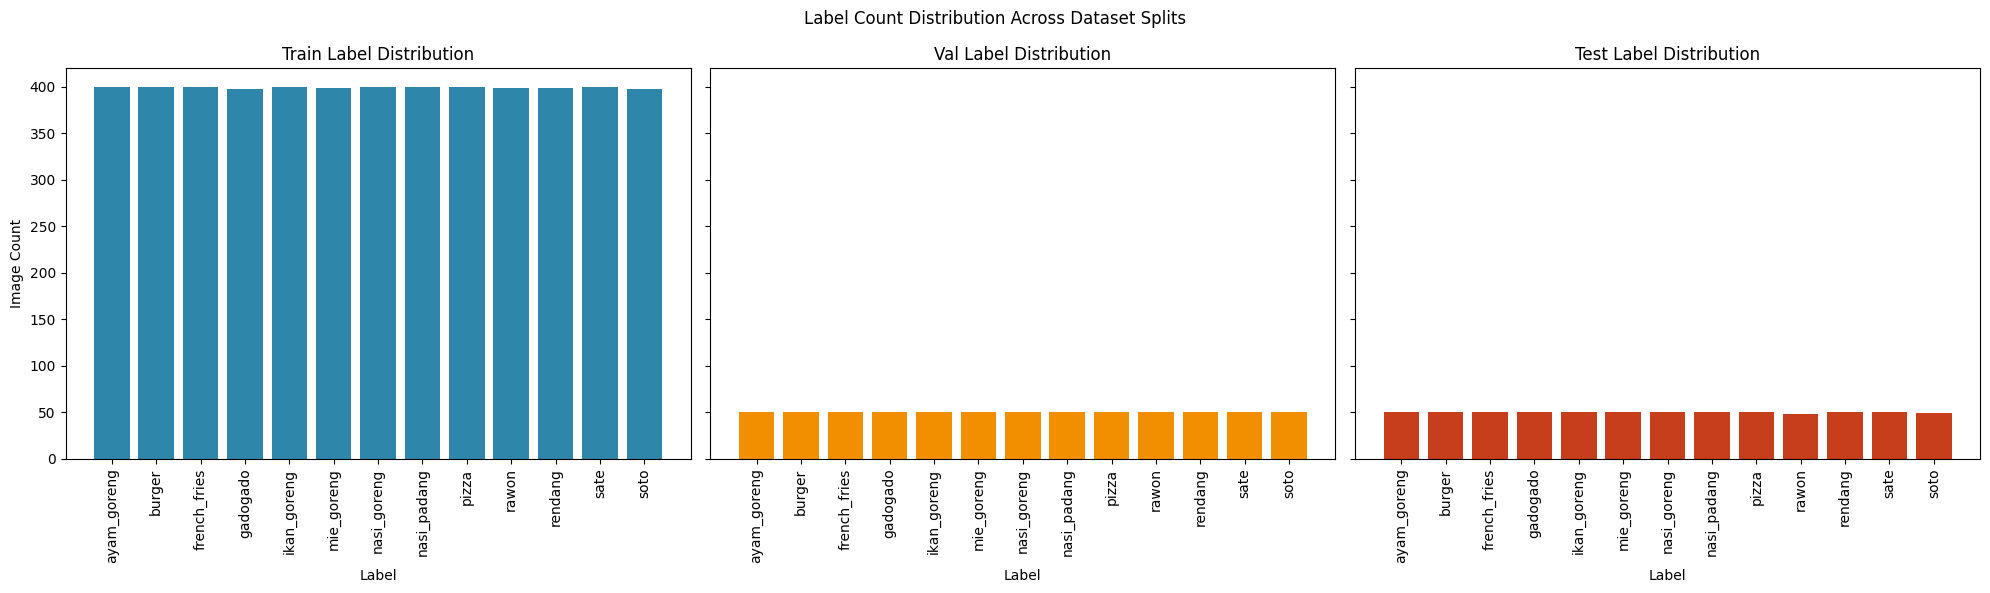

{'train': {'ayam_goreng': 400,
  'burger': 400,
  'french_fries': 400,
  'gadogado': 398,
  'ikan_goreng': 400,
  'mie_goreng': 399,
  'nasi_goreng': 400,
  'nasi_padang': 400,
  'pizza': 400,
  'rawon': 399,
  'rendang': 399,
  'sate': 400,
  'soto': 398},
 'val': {'ayam_goreng': 50,
  'burger': 50,
  'french_fries': 50,
  'gadogado': 50,
  'ikan_goreng': 50,
  'mie_goreng': 50,
  'nasi_goreng': 50,
  'nasi_padang': 50,
  'pizza': 50,
  'rawon': 50,
  'rendang': 50,
  'sate': 50,
  'soto': 50},
 'test': {'ayam_goreng': 50,
  'burger': 50,
  'french_fries': 50,
  'gadogado': 50,
  'ikan_goreng': 50,
  'mie_goreng': 50,
  'nasi_goreng': 50,
  'nasi_padang': 50,
  'pizza': 50,
  'rawon': 48,
  'rendang': 50,
  'sate': 50,
  'soto': 49}}

In [20]:
label_distribution = visualize_label_distribution(
    labeled_train_images = labeled_train_images,
    labeled_val_images = labeled_val_images,
    labeled_test_images = labeled_test_images,
    )

label_distribution

## Fungsi Visualisasi Distribusi Ukuran Gambar

Fungsi utilitas berikut membaca setiap gambar dari data training, validation, dan test, kemudian membandingkan distribusi lebar dan tinggi gambar pada seluruh split dataset.

In [21]:
from typing import Any

from PIL import Image

def visualize_image_size_distribution(
    labeled_train_images: ListLabels
    , labeled_val_images: ListLabels
    , labeled_test_images: ListLabels
) -> Dict[str, Dict[str, List[Any]]]:

    split_to_images: Dict[str, ListLabels] = {
        "train": labeled_train_images
        , "val": labeled_val_images
        , "test": labeled_test_images
    }

    size_summary: Dict[str, Dict[str, List[Any]]] = {}
    fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (20, 10), sharey = "row")
    colors = {
        "train": "#2E86AB"
        , "val": "#F18F01"
        , "test": "#C73E1D"
    }

    for each_column, (split_name, labeled_images) in enumerate(split_to_images.items()):

        widths: List[int] = []
        heights: List[int] = []
        image_sizes: List[tuple] = []

        for each_image in labeled_images:
            image_path = each_image["image_path"]

            with Image.open(image_path) as img:
                width, height = img.size

            widths.append(width)
            heights.append(height)
            image_sizes.append((width, height))

        size_summary[split_name] = {
            "widths": widths
            , "heights": heights
            , "sizes": image_sizes
        }

        axes[0, each_column].hist(widths, bins = 20, color = colors[split_name], alpha = 0.85)
        axes[0, each_column].set_title(f"{split_name.title()} Width Distribution")
        axes[0, each_column].set_xlabel("Width (pixels)")

        axes[1, each_column].hist(heights, bins = 20, color = colors[split_name], alpha = 0.85)
        axes[1, each_column].set_title(f"{split_name.title()} Height Distribution")
        axes[1, each_column].set_xlabel("Height (pixels)")

    axes[0, 0].set_ylabel("Image Count")
    axes[1, 0].set_ylabel("Image Count")
    fig.suptitle("Image Size Distribution Across Dataset Splits")
    plt.tight_layout()
    plt.show()

    return size_summary


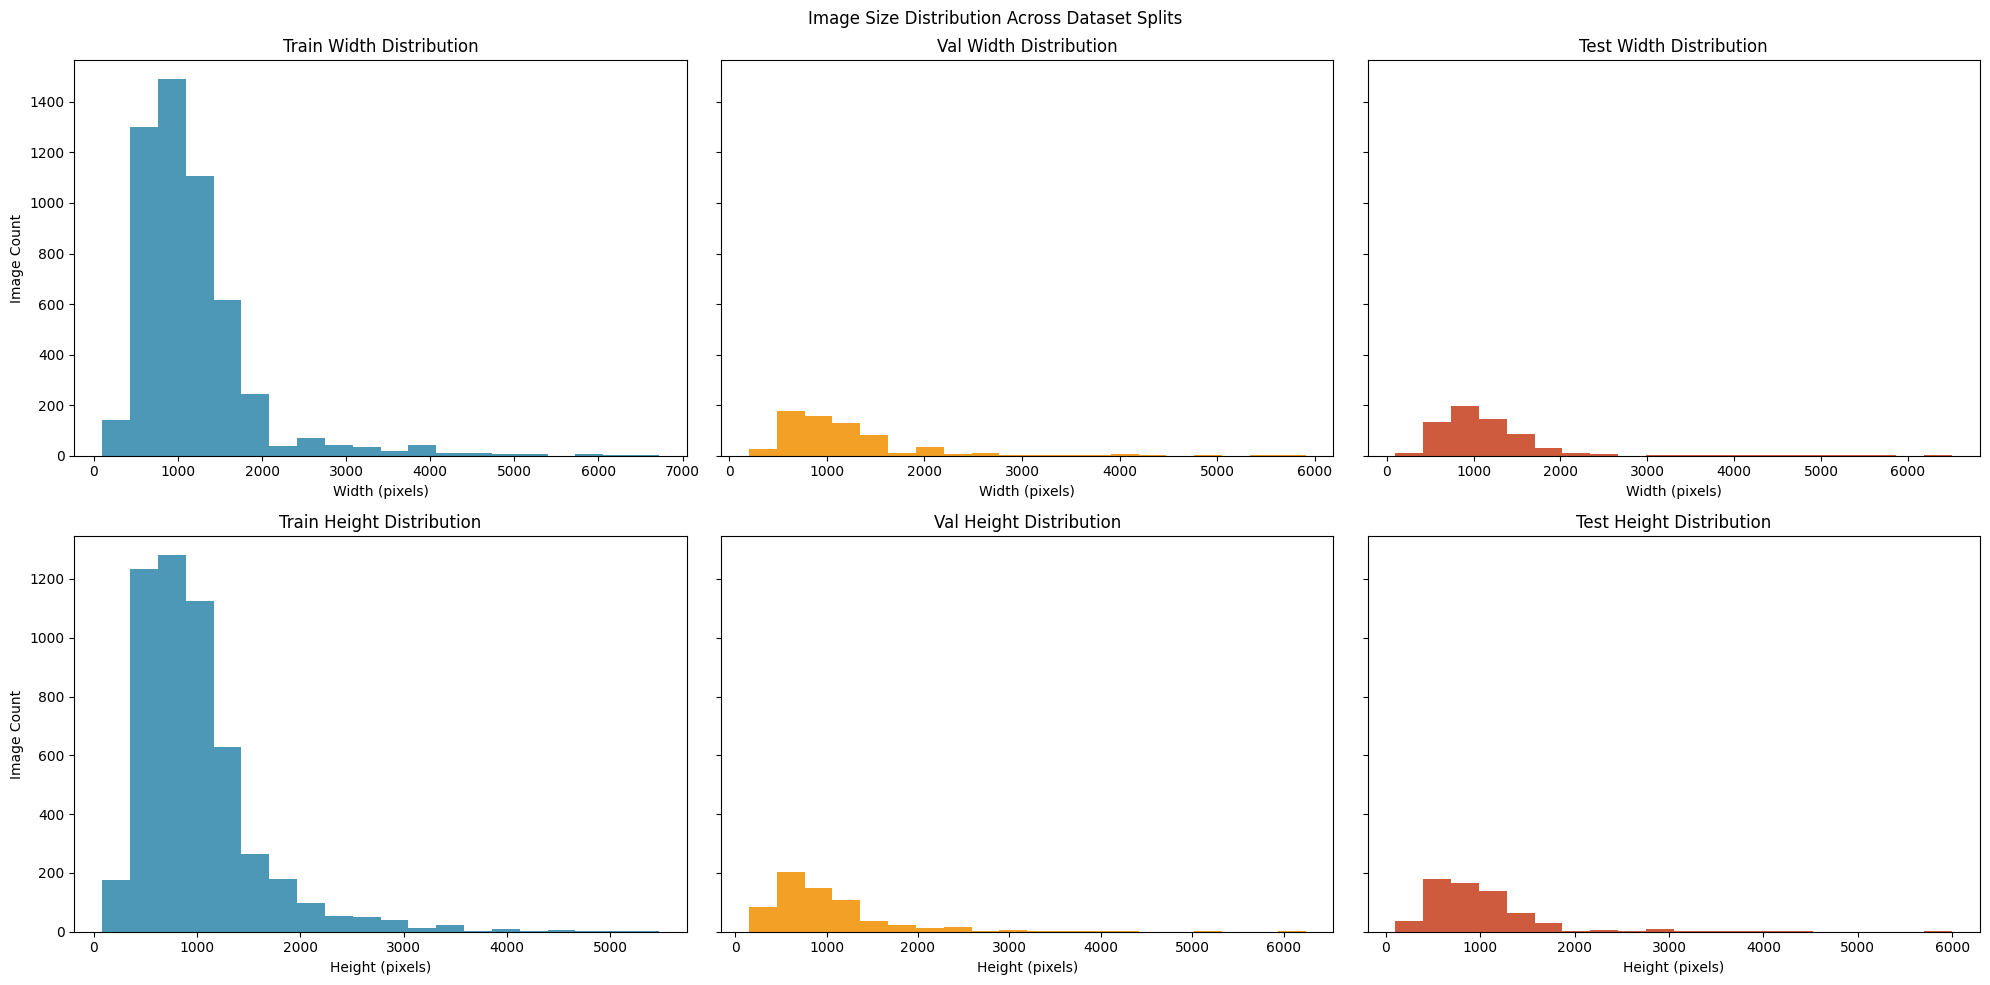

{'train': {'min_width': 100,
  'max_width': 6720,
  'min_height': 80,
  'max_height': 5472},
 'val': {'min_width': 200,
  'max_width': 5907,
  'min_height': 150,
  'max_height': 6240},
 'test': {'min_width': 100,
  'max_width': 6509,
  'min_height': 100,
  'max_height': 6000}}

In [22]:
image_size_distribution = visualize_image_size_distribution(
    labeled_train_images = labeled_train_images,
    labeled_val_images = labeled_val_images,
    labeled_test_images = labeled_test_images,
    )

{
    each_split: {
        "min_width": min(each_summary["widths"]),
        "max_width": max(each_summary["widths"]),
        "min_height": min(each_summary["heights"]),
        "max_height": max(each_summary["heights"]),
    }
    for each_split, each_summary in image_size_distribution.items()
}

Berdasarkan hasil di atas, terlihat bahwa ukuran gambar pada dataset belum seragam.

Variasi ukuran ini akan menyulitkan proses pelatihan CNN, karena model membutuhkan bentuk input yang konsisten.

Oleh sebab itu, sebelum membangun model CNN, diperlukan fungsi tambahan untuk melakukan standardisasi ukuran gambar.

## Praproses Data: Transformasi Ukuran Citra ke Format `ImageNet` `(224, 224, 3)`

Sebagaimana terlihat pada analisis sebelumnya, gambar pada dataset `indonesian_food` memiliki ukuran yang beragam.

Sebelum model CNN dibangun, ukuran gambar perlu diseragamkan agar model menerima input dengan dimensi yang konsisten.

Dalam notebook ini, ukuran target yang digunakan adalah ukuran standar pada dataset `ImageNet`, yaitu `(224, 224, 3)`.

Ukuran tersebut dipilih karena banyak arsitektur CNN populer dikembangkan dan dilatih menggunakan format input `ImageNet`. Dengan menyelaraskan ukuran citra ke format ini, eksperimen lanjutan dengan berbagai keluarga model CNN menjadi lebih mudah dilakukan.

Transformasi ukuran dilakukan melalui tiga langkah:
1. menskalakan sisi terpendek gambar menjadi `224`, sehingga rasio aspek tetap dipertahankan,
2. melakukan `center crop` pada hasil resize agar diperoleh ukuran akhir `(224, 224, 3)`,
3. membungkus kedua langkah tersebut ke dalam satu fungsi utilitas.

## Food For Thought

Pipeline preprocessing pada notebook ini melakukan `resize` pada gambar, lalu mengambil `center crop` berukuran `224 x 224`. Jelaskan bagaimana pilihan ini dapat membantu maupun merugikan performa klasifikasi pada gambar makanan. Dalam jawaban Anda, pertimbangkan kondisi ketika objek utama tidak berada tepat di tengah gambar atau ketika detail visual penting justru berada di area tepi gambar.

### Pembahasan

Pemilihan strategi `resize` lalu `center crop` ke ukuran `224 x 224` memiliki keuntungan yang jelas bagi pipeline klasifikasi. Pertama, seluruh gambar menjadi seragam sehingga dapat diproses secara efisien oleh CNN. Kedua, pendekatan ini sering membantu ketika objek utama memang berada di area tengah gambar, karena bagian yang paling relevan akan tetap dipertahankan sambil mengurangi variasi latar belakang yang tidak penting.

Akan tetapi, strategi ini juga memiliki kelemahan. Pada foto makanan, objek utama tidak selalu terletak tepat di tengah. Dalam beberapa kasus, piring, lauk pendamping, tekstur kuah, atau bentuk penyajian penting justru berada di sisi kiri, kanan, atas, atau bawah gambar. Jika bagian tersebut terpotong oleh `center crop`, model dapat kehilangan informasi visual yang penting dan akhirnya membuat prediksi yang kurang akurat.

Dengan demikian, `center crop` merupakan kompromi antara kesederhanaan dan ketahanan model. Untuk eksperimen awal, pilihan ini masih wajar dan praktis. Namun, untuk meningkatkan performa pada penelitian lanjutan, pendekatan seperti `random crop`, `data augmentation`, atau bahkan deteksi objek sebelum klasifikasi dapat dipertimbangkan agar informasi makanan yang berada di tepi gambar tidak hilang.

In [32]:
## Define function to resize the smallest dimension to 224 pixel

from PIL import Image
import numpy as np

def resize_shortest(
        img: Image.Image
) -> np.ndarray:

    """Resize an image so its shortest side becomes 224 pixels.

    This function converts the input image to RGB mode, computes a scale
    factor from the shortest spatial dimension, and resizes the image while
    preserving its aspect ratio. The resized image is returned as a NumPy
    array with three RGB channels.

    Parameters
    ----------
    img : PIL.Image.Image
        Input image to be resized.
        Default value: no default value.

    Returns
    -------
    np.ndarray
        Resized RGB image as a NumPy array with shape `(height, width, 3)`.
    """

    TARGET_SIZE: int = 224

    # Ensure the image is in RGB format
    rgb_image: Image.Image = img.convert("RGB")

    scale_factor: float = TARGET_SIZE / min(rgb_image.height, rgb_image.width)
    new_w: int = round(rgb_image.width * scale_factor)
    new_h: int = round(rgb_image.height * scale_factor)

    resized_image: Image.Image = rgb_image.resize(
        size = (new_w, new_h)
        , resample = Image.Resampling.LANCZOS
    )

    scaled_image_np: np.ndarray = np.array(resized_image)

    return scaled_image_np


In [33]:
# Define function to crop image from the center
def crop_from_center(
        img: np.ndarray
) -> np.ndarray:

    """Crop the center region of an image to 224 x 224 pixels.

    This function extracts a square crop from the center of a NumPy image
    array. It assumes the input image has already been resized so that both
    spatial dimensions are at least 224 pixels. The output preserves the
    original channel dimension and returns the centered crop as a NumPy
    array.

    Parameters
    ----------
    img : np.ndarray
        Input image as a NumPy array with shape `(height, width, channels)`.
        Default value: no default value.

    Returns
    -------
    np.ndarray
        Center-cropped image as a NumPy array with shape `(224, 224, channels)`.
    """

    TARGET_SIZE: int = 224

    image_h: int = img.shape[0]
    image_w: int = img.shape[1]

    if image_h < TARGET_SIZE or image_w < TARGET_SIZE:
        raise ValueError("Input image must be at least 224x224 before center cropping.")

    left_pt: int = (image_w - TARGET_SIZE) // 2
    right_pt: int = left_pt + TARGET_SIZE

    top_pt: int = (image_h - TARGET_SIZE) // 2
    bottom_pt: int = top_pt + TARGET_SIZE

    cropped_image_np: np.ndarray = img[top_pt:bottom_pt, left_pt:right_pt, :]

    return cropped_image_np

In [ ]:
# Gabungkan proses resize dan crop ke dalam satu fungsi

def resize_and_crop_image(
        img: Image.Image
)-> np.ndarray:

    """Resize and crop an image to shape `(224, 224, 3)`.

    This function performs two steps:
    1. Resize the image so that its shortest dimension becomes 224 pixels.
    2. Crop the resized image from the center to obtain a final shape of `(224, 224, 3)`.

    Parameters
    ----------
    img : PIL.Image.Image
        Input image to be resized and cropped.

    Returns
    -------
    np.ndarray
        Resized and center-cropped RGB image with shape `(224, 224, 3)`.
    """

    # First, resize the image while preserving aspect ratio.
    resized_img: np.ndarray = resize_shortest(img = img)

    # Second, crop the resized image from the center.
    cropped_img: np.ndarray = crop_from_center(img = resized_img)

    return cropped_img

Original Image Size: (794, 530)


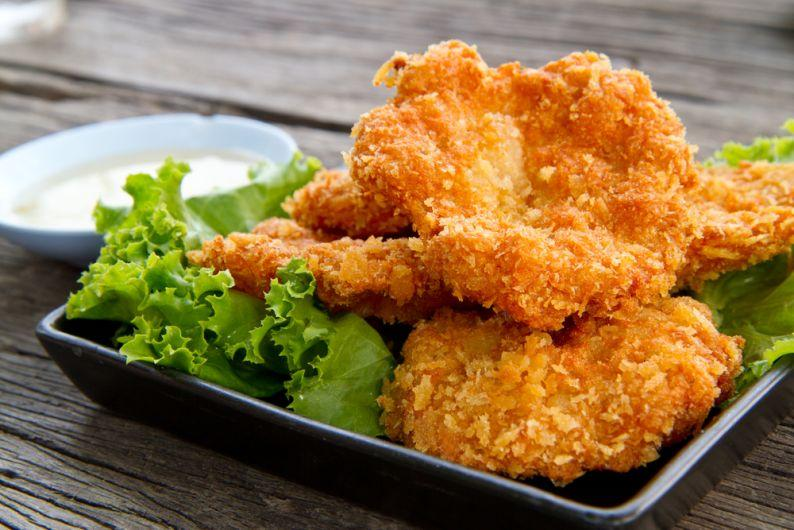

In [ ]:
# Uji fungsi resize dan crop pada satu contoh gambar

test_image_dict: Dict[str, Union[str, Path]] = labeled_train_images[0]
test_image_path: Path = test_image_dict["image_path"]
test_image: Image.Image = Image.open(test_image_path)

print(f"Original Image Size: {test_image.size}")
display(test_image)

Resized and Cropped Image Size: (224, 224, 3)


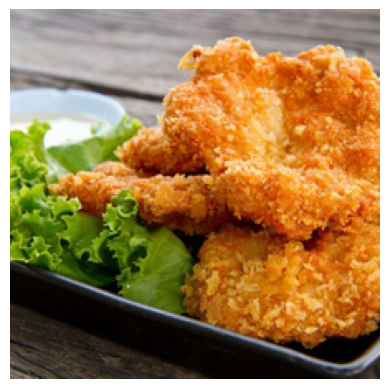

In [35]:
from matplotlib import pyplot as plt
import numpy as np

prc_img: np.ndarray = resize_and_crop_image(img = test_image)

print(f"Resized and Cropped Image Size: {prc_img.shape}")
plt.imshow(prc_img)
plt.axis("off")
plt.show()

Setelah fungsi `resize_and_crop_image` selesai disusun, langkah berikutnya adalah menyiapkan fungsi-fungsi tambahan untuk preprocessing gambar pada tahap pelatihan dan inferensi.

Fungsi-fungsi ini akan digunakan di dalam pipeline `TensorFlow Dataset` agar proses pemuatan dan preprocessing gambar dapat dilakukan secara konsisten.

In [ ]:
from typing import Tuple, List, Dict, Union
from pathlib import Path

import numpy as np
import tensorflow as tf
from PIL import Image

In [31]:
# Convert string label names into integer labels
label_names: List[str] = sorted(categories_name.values())
label_to_id: Dict[str, int] = {
    each_label : idx for idx, each_label in enumerate(label_names)
}

In [36]:
def prepare_records(
        labeled_images: ListLabels
) -> Tuple[List[str], List[int]]:

     image_paths: List[str] = [
         str(each_item["image_path"]) for each_item in labeled_images
     ]

     labels_int: List[int] = [
        label_to_id[each_item["label"]] for each_item in labeled_images
     ]

     return image_paths, labels_int

In [37]:
def load_and_preprocess_image_py(
        image_path_tensor: tf.Tensor
) -> tf.Tensor:

    image_path: str = image_path_tensor.numpy().decode("utf-8")

    with Image.open(image_path) as img:
        rc_image_np: np.ndarray = resize_and_crop_image(img = img)

    rc_image_np = rc_image_np.astype(np.float32) / 255.0

    rc_image_tf: tf.Tensor = tf.convert_to_tensor(rc_image_np)

    return rc_image_tf

In [38]:
def tf_preprocess_wrapper(
        image_path: tf.Tensor
        , label: tf.Tensor
) -> Tuple[tf.Tensor, tf.Tensor]:

    image: tf.Tensor = tf.py_function(
        func = load_and_preprocess_image_py
        , inp = [image_path]
        , Tout = tf.float32
    )

    image.set_shape((224,224,3))

    return image, label

In [26]:
def build_dataset_from_labeled_images(
        labeled_images: ListLabels
        , batch_size: int = 32
        , is_training: bool = False
) -> tf.data.Dataset:

    image_paths, labels = prepare_records(labeled_images = labeled_images)

    dst: tf.data.Dataset = tf.data.Dataset.from_tensor_slices(
        tensors = (image_paths, labels)
    )

    if is_training:
        dst = dst.shuffle(buffer_size = len(image_paths))

    dst = dst.map(tf_preprocess_wrapper, num_parallel_calls = tf.data.AUTOTUNE)
    dst = dst.batch(batch_size = batch_size)
    dst = dst.prefetch(buffer_size = tf.data.AUTOTUNE)

    return dst

## Pembangunan Model CNN

Setelah ukuran gambar berhasil diseragamkan, langkah berikutnya adalah membangun model Convolutional Neural Network (CNN) untuk tugas klasifikasi gambar.

Pada notebook ini, beberapa pendekatan arsitektur diuji. Eksperimen dimulai dari CNN kustom yang relatif sederhana, kemudian dilanjutkan dengan model berbasis VGG16 agar performa kedua pendekatan dapat dibandingkan secara langsung.

Untuk tugas klasifikasi ini, metrik evaluasi utama yang digunakan adalah `accuracy`, dengan tambahan `top-3 accuracy` sebagai metrik pendukung.

## Model 1: CNN Kustom

Sebagai model pertama, digunakan arsitektur CNN kustom yang relatif sederhana.

Struktur utama model ini adalah sebagai berikut:
* beberapa blok berulang yang terdiri atas layer konvolusi, batch normalization, aktivasi, dan max pooling,
* `MLP head` sederhana untuk mengubah fitur hasil ekstraksi menjadi prediksi kelas.

In [41]:
from typing import Tuple
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_cnn_block(
    x: tf.Tensor
    , filter: int
    , kernel_size: Tuple[int, int] = (3, 3)
    , pool_size: Tuple[int, int] = (2, 2)
    , activation: str = "relu"
) -> tf.Tensor:

    x = layers.Conv2D(filters = filter, kernel_size = kernel_size, padding = "same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(activation)(x)

    x = layers.Conv2D(filters = filter, kernel_size = kernel_size, padding = "same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(activation)(x)

    x = layers.MaxPooling2D(pool_size = pool_size)(x)

    return x


def build_model(
    input_shape: Tuple[int, int, int] = (224, 224, 3)
    , num_classes: int = len(categories_name)
    , conv_filters: Tuple[int] = (32, 64, 128, 256)
    , mlp_units : Tuple[int, int] = (128, 64)
    , activation: str = "relu"
) -> Model:

    inputs: tf.Tensor = layers.Input(shape = input_shape)
    x: tf.Tensor = inputs

    # Create repeated CNN blocks
    for each_filter in conv_filters:
        x = build_cnn_block(x = x, filter = each_filter, activation = activation)


    # Transition to MLP
    x = layers.GlobalAveragePooling2D()(x)

    # MLP head
    for each_layer in mlp_units:
        x = layers.Dense(units = each_layer)(x)
        x = layers.Activation(activation)(x)
        x = layers.Dropout(rate = 0.3)(x)

    outputs: tf.Tensor = layers.Dense(units = num_classes, activation = "softmax")(x)

    model: Model = Model(inputs = inputs, outputs = outputs)

    return model

In [42]:
cnn_model: Model = build_model()
cnn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             

 Total params: 1,218,093 (4.65 MB)

 Trainable params: 1,216,173 (4.64 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [43]:
cnn_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-4)
    , loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = False)
    , metrics = [
        "accuracy"
        , tf.keras.metrics.SparseTopKCategoricalAccuracy(k = 3, name = "top_3_accuracy")
    ]
)

Setelah arsitektur model didefinisikan dan proses kompilasi selesai dilakukan, langkah berikutnya adalah membangun dataset `TensorFlow` dengan memanfaatkan fungsi persiapan data yang telah dibuat pada bagian sebelumnya.

In [39]:
# Create folder to save the best model
from pathlib import Path

cwd: Path = Path.cwd()
model_path: Path = cwd / "keras_model"

if not model_path.exists():
    model_path.mkdir(parents = True, exist_ok = True)

In [40]:
import tensorflow as tf

BATCH_SIZE: int = 32
EPOCHS: int = 30

train_ds: tf.data.Dataset = build_dataset_from_labeled_images(
    labeled_images = labeled_train_images
    , batch_size = BATCH_SIZE
    , is_training = True
)

val_ds: tf.data.Dataset = build_dataset_from_labeled_images(
    labeled_images = labeled_val_images
    , batch_size = BATCH_SIZE
    , is_training = False
)

test_ds: tf.data.Dataset = build_dataset_from_labeled_images(
    labeled_images = labeled_test_images
    , batch_size = BATCH_SIZE
    , is_training = False
)

In [44]:
callbacks: List[tf.keras.callbacks.Callback] = [
    tf.keras.callbacks.EarlyStopping(
        monitor = "val_loss"
        , patience = 5
        , restore_best_weights = True
    )
    , tf.keras.callbacks.ReduceLROnPlateau(
        monitor = "val_loss"
        , factor = 0.5
        , patience = 2
        , min_lr = 1e-6
    )
    , tf.keras.callbacks.ModelCheckpoint(
        filepath = str(model_path / "indonesian_food_model.keras")
        , monitor = "val_loss"
        , save_best_only = True
    )
]

In [45]:
# Train Model
history: tf.keras.callbacks.History = cnn_model.fit(
    train_ds
    , validation_data = val_ds
    , epochs = EPOCHS
    , callbacks = callbacks
)

Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1890s 12s/step - accuracy: 0.2180 - loss: 2.3264 - top_3_accuracy: 0.4550 - val_accuracy: 0.0769 - val_loss: 2.7010 - val_top_3_accuracy: 0.2815 - learning_rate: 1.0000e-04
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1989s 12s/step - accuracy: 0.3666 - loss: 1.9403 - top_3_accuracy: 0.6509 - val_accuracy: 0.1615 - val_loss: 2.6860 - val_top_3_accuracy: 0.3738 - learning_rate: 1.0000e-04
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1930s 12s/step - accuracy: 0.4319 - loss: 1.7498 - top_3_accuracy: 0.7165 - val_accuracy: 0.2738 - val_loss: 2.4398 - val_top_3_accuracy: 0.5446 - learning_rate: 1.0000e-04
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 2012s 12s/step - accuracy: 0.4758 - loss: 1.6179 - top_3_accuracy: 0.7576 - val_accuracy: 0.3569 - val_loss: 2.0337 - val_top_3_accuracy: 0.7062 - learning_rate: 1.0000e-04
Epoch 5/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 2006s 12s/step - accuracy: 0.5230 - loss: 1.4701 - top_3_accuracy: 0.7915 - val_accuracy: 0.5600 - val_loss:

In [46]:
def plot_loss_history(
    history: tf.keras.callbacks.History
) -> None:

    """Plot training history across loss and accuracy metrics.

    Parameters
    ----------
    history : tf.keras.callbacks.History
        Keras History object returned by `model.fit()`.
        Default value: no default value.

    Returns
    -------
    None
        This function displays matplotlib figures and does not return a value.
    """

    history_dict = history.history
    epochs = range(1, len(history_dict.get("loss", [])) + 1)

    fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (18, 5))

    axes[0].plot(epochs, history_dict.get("loss", []), marker = "o", label = "Training Loss")
    axes[0].plot(epochs, history_dict.get("val_loss", []), marker = "o", label = "Validation Loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha = 0.3)

    axes[1].plot(epochs, history_dict.get("accuracy", []), marker = "o", label = "Training Accuracy")
    axes[1].plot(epochs, history_dict.get("val_accuracy", []), marker = "o", label = "Validation Accuracy")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(alpha = 0.3)

    axes[2].plot(
        epochs,
        history_dict.get("top_3_accuracy", []),
        marker = "o",
        label = "Training Top-3 Accuracy",
    )
    axes[2].plot(
        epochs,
        history_dict.get("val_top_3_accuracy", []),
        marker = "o",
        label = "Validation Top-3 Accuracy",
    )
    axes[2].set_title("Top-3 Accuracy")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Top-3 Accuracy")
    axes[2].legend()
    axes[2].grid(alpha = 0.3)

    for each_axis in axes:
        each_axis.set_xticks(list(epochs))

    plt.tight_layout()
    plt.show()

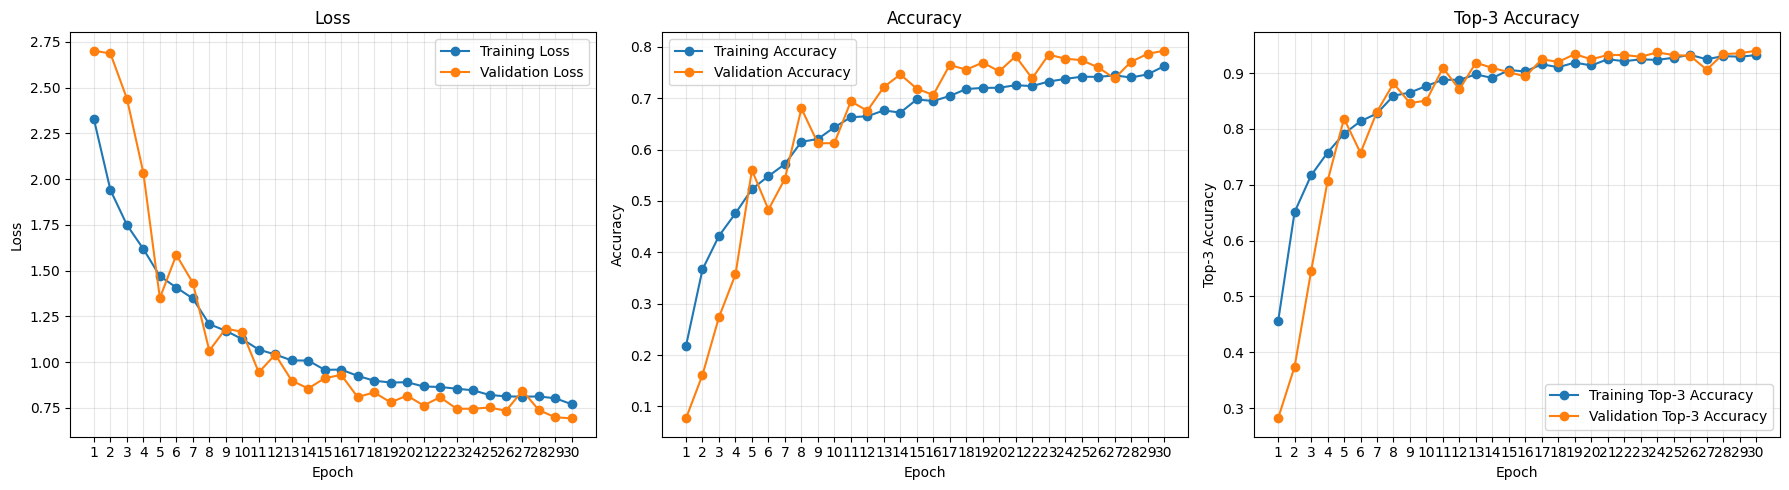

In [47]:
plot_loss_history(history = history)


Berdasarkan kurva pelatihan CNN selama 30 epoch, performa model meningkat secara bertahap, tetapi tetap terlihat adanya selisih antara performa pada data latih dan data evaluasi. Pada beberapa epoch, `validation loss` dapat tampak lebih rendah daripada `training loss`. Fenomena ini masih wajar karena loss pelatihan dihitung ketika parameter model masih terus diperbarui, sedangkan loss validasi dihitung setelah satu epoch selesai.

Namun, ketika model dievaluasi kembali dalam mode inferensi, pola yang lebih stabil terlihat dengan jelas: `train loss = 0.529`, `val loss = 0.693`, dan `test loss = 0.744`. Pola yang sama juga muncul pada akurasi, yaitu `train accuracy = 0.854`, `val accuracy = 0.792`, dan `test accuracy = 0.776`. Hasil ini menunjukkan bahwa model CNN kustom telah mempelajari pola data dengan cukup baik, tetapi masih memiliki `generalization gap`, sehingga performanya menurun ketika dihadapkan pada data yang tidak ikut dilatih.

Dengan demikian, interpretasi yang paling tepat adalah bahwa kurva pelatihan tidak cukup untuk menyimpulkan kualitas generalisasi. Evaluasi akhir pada train, validation, dan test set memberikan dasar yang lebih kuat untuk menyatakan bahwa CNN kustom bekerja dengan baik, tetapi belum menjadi model terbaik dalam eksperimen ini.

In [48]:
from pprint import pprint

cnn_train_eval = cnn_model.evaluate(
    train_ds,
    verbose = 2,
    return_dict = True,
 )

cnn_val_eval = cnn_model.evaluate(
    val_ds,
    verbose = 2,
    return_dict = True,
 )

cnn_test_eval = cnn_model.evaluate(
    test_ds,
    verbose = 2,
    return_dict = True,
 )

print("CNN Train Evaluation:")
pprint(cnn_train_eval, indent = 2)

print("CNN Validation Evaluation:")
pprint(cnn_val_eval, indent = 2)

print("CNN Test Evaluation:")
pprint(cnn_test_eval, indent = 2)

163/163 - 433s - 3s/step - accuracy: 0.8542 - loss: 0.5285 - top_3_accuracy: 0.9692
21/21 - 60s - 3s/step - accuracy: 0.7923 - loss: 0.6933 - top_3_accuracy: 0.9400
21/21 - 57s - 3s/step - accuracy: 0.7759 - loss: 0.7436 - top_3_accuracy: 0.9181
CNN Train Evaluation:
{ 'accuracy': 0.85422682762146,
  'loss': 0.5285472273826599,
  'top_3_accuracy': 0.9691892862319946}
CNN Validation Evaluation:
{ 'accuracy': 0.7923076748847961,
  'loss': 0.6932646036148071,
  'top_3_accuracy': 0.9399999976158142}
CNN Test Evaluation:
{ 'accuracy': 0.7758887410163879,
  'loss': 0.7435768246650696,
  'top_3_accuracy': 0.9180834889411926}


Hasil `cnn_model.evaluate()` memperlihatkan bahwa model CNN kustom mempertahankan pola performa yang konsisten antara data latih, validasi, dan pengujian, tetapi dengan penurunan yang cukup nyata pada data di luar training set. Secara kuantitatif, model menghasilkan `top-3 accuracy` yang masih tinggi pada validation (`0.940`) dan test (`0.918`), sehingga model masih cukup berguna sebagai sistem rekomendasi kandidat kelas. Akan tetapi, karena `test accuracy` hanya mencapai `0.776`, model ini belum cukup kuat apabila sistem membutuhkan satu prediksi tunggal yang sangat presisi.

## Food For Thought

Notebook ini melaporkan dua metrik, yaitu `accuracy` standar dan `top-3 accuracy`. Dalam konteks klasifikasi makanan Indonesia, jelaskan kapan `top-3 accuracy` menjadi metrik evaluasi yang berguna dan kapan metrik ini justru dapat membuat model tampak lebih baik daripada kemampuan sebenarnya. Dalam jawaban Anda, pertimbangkan bagaimana model akan digunakan pada aplikasi nyata.

### Pembahasan

`Top-3 accuracy` menjadi metrik yang berguna ketika model dipakai sebagai sistem bantu keputusan, bukan sebagai sistem yang harus selalu memberikan satu jawaban final. Dalam konteks klasifikasi makanan Indonesia, metrik ini relevan apabila aplikasi ingin menampilkan tiga kandidat makanan teratas kepada pengguna, lalu pengguna memilih hasil yang paling sesuai. Pada skenario seperti ini, model masih bernilai praktis walaupun prediksi peringkat pertama belum selalu benar.

Hasil eksperimen menunjukkan hal tersebut secara jelas. Model CNN kustom hanya mencapai `test accuracy = 0.776`, tetapi `test top-3 accuracy = 0.918`. Model VGG16 bahkan mencapai `test accuracy = 0.895` dan `test top-3 accuracy = 0.977`. Ini berarti bahwa label yang benar sangat sering muncul di antara tiga prediksi teratas, walaupun tidak selalu berada di posisi pertama.

Namun, `top-3 accuracy` juga dapat membuat model tampak lebih baik daripada kemampuan sebenarnya apabila aplikasi menuntut satu prediksi final yang akurat, misalnya untuk pencatatan otomatis menu, estimasi gizi tanpa verifikasi pengguna, atau integrasi ke sistem transaksi. Pada kasus tersebut, metrik yang lebih penting tetaplah `top-1 accuracy`, karena sistem tidak memperoleh manfaat penuh hanya dari fakta bahwa label benar muncul di urutan kedua atau ketiga. Oleh sebab itu, `top-3 accuracy` sebaiknya dibaca sebagai metrik pelengkap, bukan pengganti akurasi utama.

## Model 2: Transfer Learning Berbasis VGG16

Pada model kedua, pendekatan yang digunakan adalah `transfer learning` dengan backbone `VGG16` yang telah dipra-latih pada dataset `ImageNet`. Pada implementasi notebook ini, backbone VGG16 digunakan sebagai pengekstrak fitur (`trainable_backbone = False`), kemudian ditambahkan `classification head` baru yang disesuaikan dengan 13 kelas makanan Indonesia.

Pendekatan ini berbeda dari `fine-tuning` penuh. Pada fine-tuning, sebagian atau seluruh layer backbone ikut diperbarui selama training. Sementara itu, pada eksperimen ini, bobot pralatih VGG16 dipertahankan, sehingga proses pembelajaran berfokus pada layer klasifikasi di bagian akhir. Strategi ini relevan ketika dataset target tidak terlalu besar, tetapi tetap memiliki kemiripan visual yang cukup dengan pola umum yang sudah dipelajari dari ImageNet.

## Food For Thought

Notebook ini membandingkan CNN kustom dengan model transfer learning berbasis VGG16 yang telah dipra-latih pada ImageNet. Jelaskan mengapa model pralatih dapat memberikan performa yang lebih baik pada dataset ini, tetapi juga paparkan situasi ketika CNN kustom yang lebih sederhana tetap menjadi pilihan yang lebih tepat. Dalam jawaban Anda, pertimbangkan ukuran dataset, biaya komputasi, dan kemiripan antara fitur ImageNet dan citra makanan Indonesia.

### Pembahasan

Model pralatih seperti VGG16 berpotensi memberikan performa yang lebih baik karena telah mempelajari banyak pola visual umum dari `ImageNet`, seperti tepi, tekstur, kontur, dan komposisi bentuk. Walaupun dataset target pada notebook ini berisi makanan Indonesia, banyak karakteristik visual dasar tetap serupa dengan objek-objek alami lain yang sudah dikenali oleh model pralatih. Hal ini menjelaskan mengapa pendekatan transfer learning pada eksperimen ini menghasilkan performa lebih tinggi daripada CNN kustom.

Hasil aktual mendukung argumen tersebut. Model VGG16 mencapai `test accuracy = 0.895` dan `test top-3 accuracy = 0.977`, sedangkan CNN kustom mencapai `test accuracy = 0.776` dan `test top-3 accuracy = 0.918`. Dengan jumlah data latih sekitar 5.193 gambar, penggunaan fitur pralatih memberi keuntungan penting karena model tidak harus belajar seluruh representasi visual dari nol.

Meskipun demikian, CNN kustom tetap dapat menjadi pilihan yang lebih baik dalam beberapa situasi. Pertama, model yang lebih sederhana biasanya lebih ringan dan lebih murah secara komputasi untuk training maupun deployment. Kedua, jika sistem akan dijalankan pada perangkat dengan sumber daya terbatas, model yang lebih kecil dapat lebih praktis. Ketiga, jika domain citra sangat berbeda dari ImageNet atau jika peneliti ingin kendali arsitektural yang lebih tinggi, model kustom dapat menjadi ruang eksperimen yang lebih fleksibel. Dengan kata lain, VGG16 lebih unggul untuk performa pada eksperimen ini, tetapi CNN kustom tetap relevan ketika prioritas utama adalah efisiensi, kesederhanaan, atau eksplorasi arsitektur.

In [49]:
from typing import Tuple

import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np

# We need to modify the image pre-processing
# from `rc_image_np = rc_image_np.astype(np.float32) / 255.0` --> which is used in our custom CNN
# into
# ```Python
# rc_image_np = rc_image_np.astype(np.float32)
# rc_image_np = tf.keras.applications.vgg16.preprocess_input(rc_image_np)
# ```

def load_and_preprocess_image_for_vgg(
        image_path_tensor: tf.Tensor
) -> tf.Tensor:

    image_path: str = image_path_tensor.numpy().decode("utf-8")

    with Image.open(image_path) as img:
        rc_image_np: np.ndarray = resize_and_crop_image(img = img)

    rc_image_np = rc_image_np.astype(np.float32)
    rc_image_np = tf.keras.applications.vgg16.preprocess_input(rc_image_np)

    rc_image_tf: tf.Tensor = tf.convert_to_tensor(rc_image_np)

    return rc_image_tf

In [50]:
def tf_preprocess_wrapper_for_vgg(
        image_path: tf.Tensor
        , label: tf.Tensor
) -> Tuple[tf.Tensor, tf.Tensor]:

    image: tf.Tensor = tf.py_function(
        func = load_and_preprocess_image_for_vgg
        , inp = [image_path]
        , Tout = tf.float32
    )

    image.set_shape((224,224,3))

    return image, label

In [51]:
def build_dataset_from_labeled_images_for_vgg(
        labeled_images: ListLabels
        , batch_size: int = 32
        , is_training: bool = False
) -> tf.data.Dataset:

    image_paths, labels = prepare_records(labeled_images = labeled_images)

    dst: tf.data.Dataset = tf.data.Dataset.from_tensor_slices(
        tensors = (image_paths, labels)
    )

    if is_training:
        dst = dst.shuffle(buffer_size = len(image_paths))

    dst = dst.map(tf_preprocess_wrapper_for_vgg, num_parallel_calls = tf.data.AUTOTUNE)
    dst = dst.batch(batch_size = batch_size)
    dst = dst.prefetch(buffer_size = tf.data.AUTOTUNE)

    return dst

In [52]:
import tensorflow as tf

BATCH_SIZE: int = 32
EPOCHS: int = 30

train_ds: tf.data.Dataset = build_dataset_from_labeled_images_for_vgg(
    labeled_images = labeled_train_images
    , batch_size = BATCH_SIZE
    , is_training = True
)

val_ds: tf.data.Dataset = build_dataset_from_labeled_images_for_vgg(
    labeled_images = labeled_val_images
    , batch_size = BATCH_SIZE
    , is_training = False
)

test_ds: tf.data.Dataset = build_dataset_from_labeled_images_for_vgg(
    labeled_images = labeled_test_images
    , batch_size = BATCH_SIZE
    , is_training = False
)

In [53]:
from typing import Tuple
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_vgg16_model(
        input_shape: Tuple[int, int, int] = (224, 224, 3)
        , num_classes: int = len(categories_name)
        , trainable_backbone: bool = False
) -> Model:

    inputs: tf.Tensor = layers.Input(shape = input_shape)

    # Here, we are using VGGNet16 as the basis of our CNN
    vgg_base: Model = tf.keras.applications.VGG16(
        include_top = False
        , weights = "imagenet"
        , input_tensor = inputs
    )

    vgg_base.trainable = trainable_backbone

    # Attaching the VGGNet Model to MLP like we did earlier
    x: tf.Tensor = vgg_base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation = "relu")(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation = "relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs: tf.Tensor = layers.Dense(num_classes, activation = "softmax")(x)

    cnn_model: Model = Model(
        inputs = inputs
        , outputs = outputs
    )

    return cnn_model

In [54]:
vgg_model: Model = build_vgg16_model()

vgg_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-4)
    , loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = False)
    , metrics = [
        "accuracy"
        , tf.keras.metrics.SparseTopKCategoricalAccuracy(k = 3, name = "top_3_accuracy")
    ]
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 18s 0us/step


In [55]:
callbacks: List[tf.keras.callbacks.Callback] = [
    tf.keras.callbacks.EarlyStopping(
        monitor = "val_loss"
        , patience = 5
        , restore_best_weights = True
    )
    , tf.keras.callbacks.ReduceLROnPlateau(
        monitor = "val_loss"
        , factor = 0.5
        , patience = 2
        , min_lr = 1e-6
    )
    , tf.keras.callbacks.ModelCheckpoint(
        filepath = str(model_path / "vgg_indonesian_food_model.keras")
        , monitor = "val_loss"
        , save_best_only = True
    )
]

In [56]:
vgg_history: tf.keras.callbacks.History = vgg_model.fit(
    train_ds
    , validation_data = val_ds
    , epochs = EPOCHS
    , callbacks = callbacks
)

Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 2176s 13s/step - accuracy: 0.1670 - loss: 6.2123 - top_3_accuracy: 0.3830 - val_accuracy: 0.4492 - val_loss: 1.7478 - val_top_3_accuracy: 0.6892 - learning_rate: 1.0000e-04
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 2163s 13s/step - accuracy: 0.3108 - loss: 2.7830 - top_3_accuracy: 0.5665 - val_accuracy: 0.5662 - val_loss: 1.3892 - val_top_3_accuracy: 0.7785 - learning_rate: 1.0000e-04
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1939s 12s/step - accuracy: 0.3980 - loss: 2.1190 - top_3_accuracy: 0.6490 - val_accuracy: 0.6415 - val_loss: 1.2158 - val_top_3_accuracy: 0.8077 - learning_rate: 1.0000e-04
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1918s 12s/step - accuracy: 0.4741 - loss: 1.7503 - top_3_accuracy: 0.7246 - val_accuracy: 0.6815 - val_loss: 1.0775 - val_top_3_accuracy: 0.8369 - learning_rate: 1.0000e-04
Epoch 5/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1816s 11s/step - accuracy: 0.5301 - loss: 1.5414 - top_3_accuracy: 0.7614 - val_accuracy: 0.7154 - val_loss:

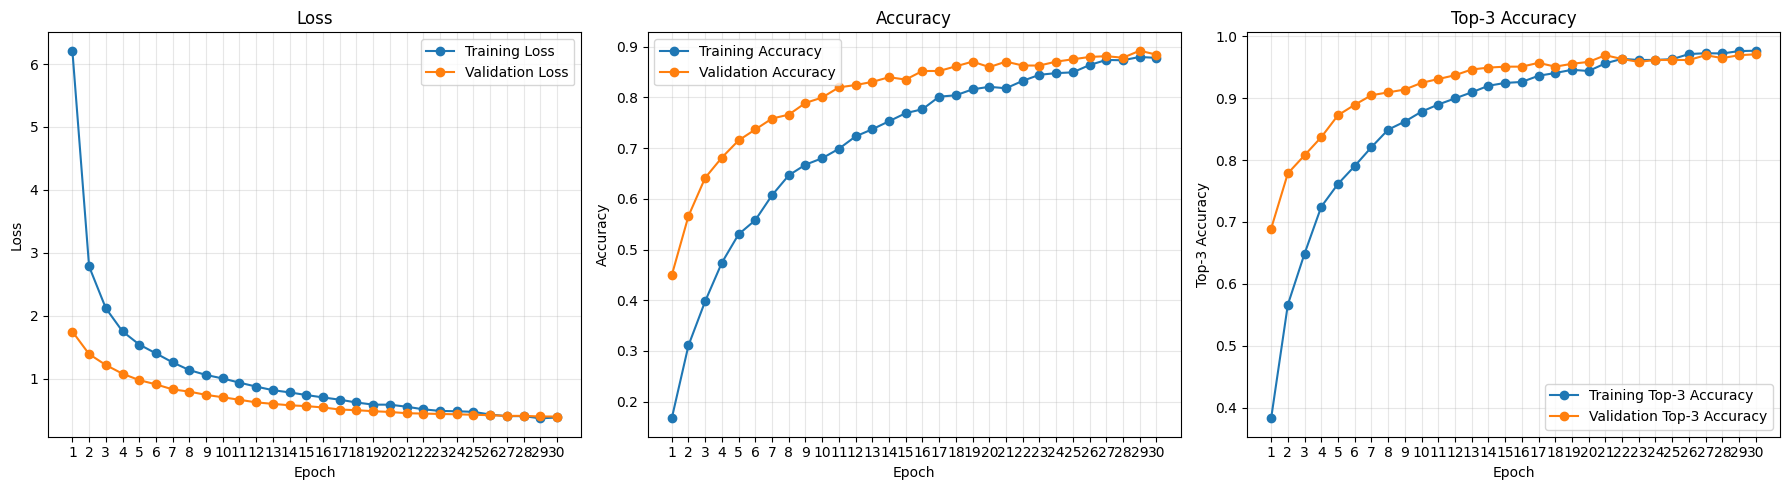

In [57]:
plot_loss_history(history = vgg_history)

In [58]:
from pprint import pprint

vgg_train_eval = vgg_model.evaluate(
    train_ds,
    verbose = 2,
    return_dict = True,
 )

vgg_val_eval = vgg_model.evaluate(
    val_ds,
    verbose = 2,
    return_dict = True,
 )

vgg_test_eval = vgg_model.evaluate(
    test_ds,
    verbose = 2,
    return_dict = True,
 )

print("VGG Train Evaluation:")
pprint(vgg_train_eval, indent = 2)

print("VGG Validation Evaluation:")
pprint(vgg_val_eval, indent = 2)

print("VGG Test Evaluation:")
pprint(vgg_test_eval, indent = 2)

163/163 - 1956s - 12s/step - accuracy: 0.9650 - loss: 0.1553 - top_3_accuracy: 0.9963
21/21 - 240s - 11s/step - accuracy: 0.8846 - loss: 0.3967 - top_3_accuracy: 0.9708
21/21 - 235s - 11s/step - accuracy: 0.8949 - loss: 0.3645 - top_3_accuracy: 0.9768
VGG Train Evaluation:
{ 'accuracy': 0.964952826499939,
  'loss': 0.15532806515693665,
  'top_3_accuracy': 0.9963412284851074}
VGG Validation Evaluation:
{ 'accuracy': 0.8846153616905212,
  'loss': 0.3967112898826599,
  'top_3_accuracy': 0.9707692265510559}
VGG Test Evaluation:
{ 'accuracy': 0.8948995471000671,
  'loss': 0.36451900005340576,
  'top_3_accuracy': 0.9768160581588745}


## Perbandingan Akhir

Perbandingan akhir harus difokuskan pada performa data validasi dan pengujian, bukan hanya pada performa data latih. Pada eksperimen ini, model `vgg16_transfer_learning` memberikan hasil terbaik dengan `val_accuracy = 0.885`, `test_accuracy = 0.895`, `val_top_3_accuracy = 0.971`, dan `test_top_3_accuracy = 0.977`. Sebaliknya, model `custom_cnn` menghasilkan `val_accuracy = 0.792`, `test_accuracy = 0.776`, `val_top_3_accuracy = 0.940`, dan `test_top_3_accuracy = 0.918`.

Berdasarkan hasil tersebut, model VGG16 lebih unggul baik dari sisi akurasi utama maupun kemampuan memasukkan label benar ke dalam tiga prediksi teratas. Oleh karena itu, pada notebook ini, model VGG16 dapat dinyatakan sebagai model terbaik di antara dua pendekatan yang diuji.

In [60]:
import pandas as pd

comparison_df = pd.DataFrame(
    [
        {
            "model": "custom_cnn",
            "val_loss": cnn_val_eval.get("loss"),
            "val_accuracy": cnn_val_eval.get("accuracy"),
            "val_top_3_accuracy": cnn_val_eval.get("top_3_accuracy"),
            "test_loss": cnn_test_eval.get("loss"),
            "test_accuracy": cnn_test_eval.get("accuracy"),
            "test_top_3_accuracy": cnn_test_eval.get("top_3_accuracy"),
        },
        {
            "model": "vgg16_transfer_learning",
            "val_loss": vgg_val_eval.get("loss"),
            "val_accuracy": vgg_val_eval.get("accuracy"),
            "val_top_3_accuracy": vgg_val_eval.get("top_3_accuracy"),
            "test_loss": vgg_test_eval.get("loss"),
            "test_accuracy": vgg_test_eval.get("accuracy"),
            "test_top_3_accuracy": vgg_test_eval.get("top_3_accuracy"),
        },
    ]
)

comparison_df.sort_values(by = ["test_accuracy", "test_top_3_accuracy"], ascending = False)

,model,val_loss,val_accuracy,val_top_3_accuracy,test_loss,test_accuracy,test_top_3_accuracy
1,vgg16_transfer_learning,0.396711,0.884615,0.970769,0.364519,0.894900,0.976816
0,custom_cnn,0.693265,0.792308,0.940000,0.743577,0.775889,0.918083


## Kesimpulan

Berdasarkan seluruh rangkaian eksperimen, dataset makanan Indonesia yang digunakan pada notebook ini memiliki distribusi kelas yang relatif seimbang pada data training, validasi, dan pengujian. Setelah seluruh gambar distandardisasi ke ukuran `224 x 224 x 3`, dua pendekatan model diuji, yaitu CNN kustom dan transfer learning berbasis VGG16.

Hasil akhir menunjukkan bahwa model `vgg16_transfer_learning` merupakan model terbaik pada eksperimen ini. Model tersebut mencapai `validation accuracy = 0.885` dan `test accuracy = 0.895`, dengan `test top-3 accuracy = 0.977`. Sementara itu, model `custom_cnn` mencapai `validation accuracy = 0.792` dan `test accuracy = 0.776`, dengan `test top-3 accuracy = 0.918`. Dengan demikian, transfer learning terbukti memberikan representasi fitur yang lebih kuat untuk tugas klasifikasi makanan Indonesia pada dataset ini.

## Saran

Untuk pengembangan berikutnya, terdapat beberapa saran yang layak dipertimbangkan. Pertama, proses preprocessing dapat diperluas dengan `data augmentation` seperti rotasi ringan, pergeseran, `random crop`, dan perubahan pencahayaan agar model lebih tahan terhadap variasi foto nyata. Kedua, eksperimen dapat diperluas ke arsitektur yang lebih modern dan efisien, seperti MobileNet, EfficientNet, atau fine-tuning parsial pada backbone VGG16. Ketiga, untuk training berdurasi panjang, penggunaan checkpoint berkala per epoch dapat ditambahkan sebagai pelengkap checkpoint model terbaik agar risiko kehilangan progres dapat ditekan.

## Kendala yang Dialami

Kendala utama dalam eksperimen ini adalah durasi training yang sangat panjang. Berdasarkan proses yang dijalani, pelatihan untuk masing-masing model dapat berlangsung sangat lama, bahkan melebihi 900 menit. Kondisi ini meningkatkan risiko interupsi proses, keterbatasan sumber daya komputasi, dan waktu iterasi eksperimen yang menjadi kurang efisien. Selain itu, variasi ukuran gambar asli juga menambah kompleksitas preprocessing karena seluruh citra harus dinormalisasi terlebih dahulu sebelum dapat digunakan oleh model.

Secara keseluruhan, notebook ini berhasil menunjukkan bahwa pendekatan yang lebih kuat secara representasi, yaitu transfer learning berbasis VGG16, memberikan hasil yang lebih baik daripada CNN kustom pada tugas klasifikasi makanan Indonesia. Namun, biaya komputasi, waktu training, dan strategi penyimpanan hasil tetap menjadi aspek penting yang perlu diperhatikan pada eksperimen lanjutan.